# PhysiCell Uptake: Cell-Position Comparison

This sweep isolates the effect of cell placement. It compares the benchmark `cells_10.csv` coordinates (12 cells) with the 12 voxel centers nearest the origin for each voxel size. Both layouts use the same cell count, uptake rate, diffusion time step, and volume.

All scores use the PhysiCell domain-average concentration against the analytical average concentration.

## Setup

Define project paths, the requested parameter grid, both cell-position layouts, and plotting defaults.

In [19]:
from pathlib import Path
import os
import shutil
import subprocess
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pctk import multicellds

ROOT = Path('/home/tntiniak/Work/observatory_benchmark')
CODE_DIR = ROOT / 'PhysiCell' / 'code'
CONFIG_DIR = CODE_DIR / 'config'
TEMPLATE_XML = CONFIG_DIR / '__tmp_uptake_tune.xml'
WORKING_XML = CONFIG_DIR / '__generated_uptake_position_comparison_case.xml'
REFERENCE_CELLS_CSV = CODE_DIR / 'user_projects' / 'decay_study' / 'config' / 'cells_10.csv'
VOXEL_CELLS_CSV = CONFIG_DIR / '__generated_inner_voxel_cells.csv'
RESULTS_ROOT = ROOT / 'PhysiCell' / 'results' / 'diffusion_uptake_cell_position_comparison'
ANALYTICAL_CSV = ROOT / 'analytical_solutions' / 'diffusion' / 'Cellsatcenter' / 'analytical_values.csv'
OUTPUT_FILENAME = 'physicell_uptake_plot_data.csv'

VOXEL_SIZES_UM = [5.0, 10.0, 20.0, 40.0]
DT_DIFFUSION_MIN = [0.05, 0.1]
TOTAL_VOLUMES_UM3 = [1, 523.0, 1000.0]
UPTAKE_RATE_PER_MIN = 12044.0
LAYOUTS = {'cells_10': REFERENCE_CELLS_CSV, 'inner_voxels': VOXEL_CELLS_CSV}

plt.rcParams.update({'figure.dpi': 160, 'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 8})
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
assert REFERENCE_CELLS_CSV.exists(), f'Missing {REFERENCE_CELLS_CSV}'

## Baseline Simulation Helpers

Create run identifiers, generate the inner-voxel layout, configure each PhysiCell XML case, and extract the original center and cell-voxel measurements.

In [20]:
def format_token(value: float) -> str:
    return f'{value:g}'.replace('-', 'm').replace('.', 'p')


def build_run_id(layout: str, dx_um: float, dt_diffusion: float, total_volume_um3: float) -> str:
    return f'{layout}__dx_{format_token(dx_um)}um__dtdiff_{format_token(dt_diffusion)}min__volume_{format_token(total_volume_um3)}um3'


def voxel_axis(dx_um: float, lower_um: float = -120.0, upper_um: float = 120.0) -> np.ndarray:
    count = int(round((upper_um - lower_um) / dx_um))
    return lower_um + (np.arange(count, dtype=float) + 0.5) * dx_um


def generate_inner_voxel_positions(dx_um: float, cell_count: int) -> np.ndarray:
    axis = voxel_axis(dx_um)
    z_um = axis[np.abs(axis).argmin()]
    candidates = [(x_um, y_um) for x_um in axis for y_um in axis]
    candidates.sort(key=lambda point: (point[0] ** 2 + point[1] ** 2, abs(point[0]), abs(point[1]), point[0], point[1]))
    return np.array([[x_um, y_um, z_um, 0.0] for x_um, y_um in candidates[:cell_count]], dtype=float)


def write_inner_voxel_cells(dx_um: float) -> np.ndarray:
    reference_positions = np.loadtxt(REFERENCE_CELLS_CSV, delimiter=',', ndmin=2)
    positions = generate_inner_voxel_positions(dx_um, len(reference_positions))
    np.savetxt(VOXEL_CELLS_CSV, positions, delimiter=',', fmt='%.10g')
    return positions


def nearest_axis_index(axis: np.ndarray, coordinate: float) -> int:
    return int(np.abs(axis - coordinate).argmin())


def bracketing_indices(axis: np.ndarray, coordinate: float = 0.0) -> tuple[int, int]:
    upper = int(np.searchsorted(axis, coordinate, side='left'))
    upper = min(max(upper, 1), len(axis) - 1)
    return upper - 1, upper


def center_estimators(microenvironment: np.ndarray) -> dict[str, float]:
    x_axis, y_axis, z_axis = (np.unique(microenvironment[index]) for index in range(3))
    concentration = microenvironment[4] / 602.2
    dimensions = (len(x_axis), len(y_axis), len(z_axis))
    x0, x1 = bracketing_indices(x_axis)
    y0, y1 = bracketing_indices(y_axis)
    z0, z1 = bracketing_indices(z_axis)
    corners = {
        (ix, iy, iz): concentration[np.ravel_multi_index((ix, iy, iz), dimensions)]
        for ix in (x0, x1) for iy in (y0, y1) for iz in (z0, z1)
    }

    lower = corners[(x0, y0, z0)]
    upper = corners[(x1, y1, z1)]
    corner_mean = float(np.mean(list(corners.values())))
    trilinear = 0.0
    for ix, x_weight in ((x0, 0.5), (x1, 0.5)):
        for iy, y_weight in ((y0, 0.5), (y1, 0.5)):
            for iz, z_weight in ((z0, 0.5), (z1, 0.5)):
                trilinear += x_weight * y_weight * z_weight * corners[(ix, iy, iz)]

    return {
        'center_lower_voxel_uM': lower,
        'center_upper_voxel_uM': upper,
        'center_corner_mean_uM': corner_mean,
        'center_trilinear_uM': trilinear,
    }


def cell_voxel_indices(microenvironment: np.ndarray, cell_positions: np.ndarray) -> tuple[set[int], tuple[int, int, int]]:
    x_axis, y_axis, z_axis = (np.unique(microenvironment[index]) for index in range(3))
    dimensions = (len(x_axis), len(y_axis), len(z_axis))
    indices = {
        np.ravel_multi_index(
            (
                nearest_axis_index(x_axis, x_um),
                nearest_axis_index(y_axis, y_um),
                nearest_axis_index(z_axis, z_um),
            ),
            dimensions,
        )
        for x_um, y_um, z_um in cell_positions
    }
    return indices, dimensions


def cell_voxel_average(microenvironment: np.ndarray, cell_positions: np.ndarray) -> tuple[float, int]:
    voxel_indices, _ = cell_voxel_indices(microenvironment, cell_positions)
    concentration = microenvironment[4] / 602.2
    return float(concentration[list(voxel_indices)].mean()), len(voxel_indices)


def cell_voxel_window_average(microenvironment: np.ndarray, cell_positions: np.ndarray) -> tuple[float, int]:
    occupied_indices, dimensions = cell_voxel_indices(microenvironment, cell_positions)
    window_indices = set()
    for flat_index in occupied_indices:
        ix, iy, iz = np.unravel_index(flat_index, dimensions)
        for neighbor_x in range(max(0, ix - 1), min(dimensions[0], ix + 2)):
            for neighbor_y in range(max(0, iy - 1), min(dimensions[1], iy + 2)):
                for neighbor_z in range(max(0, iz - 1), min(dimensions[2], iz + 2)):
                    window_indices.add(np.ravel_multi_index((neighbor_x, neighbor_y, neighbor_z), dimensions))
    concentration = microenvironment[4] / 602.2
    return float(concentration[list(window_indices)].mean()), len(window_indices)


def configure_case_xml(output_dir: Path, cell_positions_csv: Path, dx_um: float, dt_diffusion: float, total_volume_um3: float) -> None:
    tree = ET.parse(TEMPLATE_XML)
    root = tree.getroot()
    for axis_name in ['dx', 'dy', 'dz']:
        root.find(f'.//domain/{axis_name}').text = str(dx_um)
    root.find('.//overall/dt_diffusion').text = str(dt_diffusion)
    root.find('.//cell_definitions//secretion//substrate/uptake_rate').text = str(UPTAKE_RATE_PER_MIN)
    root.find('.//cell_definitions//volume/total').text = str(total_volume_um3)
    root.find('.//cell_definitions//volume/nuclear').text = str(0.1 * total_volume_um3)
    root.find('.//save/folder').text = os.path.relpath(output_dir, CODE_DIR)
    position_node = root.find('.//initial_conditions/cell_positions')
    position_node.find('folder').text = './' + os.path.relpath(cell_positions_csv.parent, CODE_DIR)
    position_node.find('filename').text = cell_positions_csv.name
    tree.write(WORKING_XML, encoding='utf-8', xml_declaration=False)


def run_physicell_case() -> None:
    completed = subprocess.run(['./project', str(WORKING_XML)], cwd=CODE_DIR, capture_output=True, text=True)
    if completed.returncode:
        raise RuntimeError(f'PhysiCell failed.\nSTDOUT:\n{completed.stdout[-4000:]}\nSTDERR:\n{completed.stderr[-4000:]}')


def load_concentrations(folder: Path, cell_positions_csv: Path) -> pd.DataFrame:
    cell_positions = np.loadtxt(cell_positions_csv, delimiter=',', usecols=(0, 1, 2), ndmin=2)
    snapshots = []
    for xml_path in sorted(folder.glob('output*.xml')):
        if xml_path.stat().st_size:
            current_time = ET.parse(xml_path).getroot().findtext('.//current_time')
            if current_time is not None:
                snapshots.append(float(current_time))

    reader = multicellds.MultiCellDS(output_folder=str(folder))
    measurements = []
    for _, field in reader.microenvironment_as_matrix_iterator():
        values = center_estimators(field)
        values['average_uM'] = field[4].mean() / 602.2
        values['cell_voxel_average_uM'], values['unique_cell_voxel_count'] = cell_voxel_average(field, cell_positions)
        values['cell_voxel_window_average_uM'], values['unique_cell_window_voxel_count'] = cell_voxel_window_average(field, cell_positions)
        measurements.append(values)

    if len(snapshots) != len(measurements):
        raise ValueError(f'Snapshot count ({len(snapshots)}) does not match field count ({len(measurements)}) in {folder}')
    return pd.DataFrame(measurements).assign(time_min=np.round(snapshots, 4))

## Additional Concentration Samplers

Add coordinate-based interpolation and local neighborhood samplers used to estimate concentration at the center and at cell locations.

In [21]:
def trilinear_sample(field, point):
    axes = tuple(np.unique(field[index]) for index in range(3))
    density = field[4] / 602.2
    dims = tuple(len(axis) for axis in axes)
    brackets = [bracketing_indices(axis, value) for axis, value in zip(axes, point)]
    weights = [(value - axis[low]) / (axis[high] - axis[low]) for axis, value, (low, high) in zip(axes, point, brackets)]
    return float(sum(
        ((1 - weights[0]) if ix == brackets[0][0] else weights[0])
        * ((1 - weights[1]) if iy == brackets[1][0] else weights[1])
        * ((1 - weights[2]) if iz == brackets[2][0] else weights[2])
        * density[np.ravel_multi_index((ix, iy, iz), dims)]
        for ix in brackets[0] for iy in brackets[1] for iz in brackets[2]
    ))


def neighborhood_sample(field, point, mode, radius_um=None):
    axes = tuple(np.unique(field[index]) for index in range(3))
    density = field[4] / 602.2
    dims = tuple(len(axis) for axis in axes)
    spacing = np.array([np.diff(axis).mean() for axis in axes])
    scale = radius_um if radius_um is not None else float(spacing.min())
    center = tuple(nearest_axis_index(axis, value) for axis, value in zip(axes, point))
    reach = max(1, int(np.ceil(3 * scale / spacing.min())))
    values, weights = [], []
    for ix in range(max(0, center[0] - reach), min(dims[0], center[0] + reach + 1)):
        for iy in range(max(0, center[1] - reach), min(dims[1], center[1] + reach + 1)):
            for iz in range(max(0, center[2] - reach), min(dims[2], center[2] + reach + 1)):
                distance = float(np.linalg.norm(np.array([axes[0][ix], axes[1][iy], axes[2][iz]]) - point))
                if mode == 'inverse_distance':
                    weight = 1 / max(distance, 0.25 * spacing.min())
                elif mode == 'gaussian':
                    weight = np.exp(-0.5 * (distance / scale) ** 2)
                elif distance <= scale + 0.5 * np.linalg.norm(spacing):
                    weight = 1.0
                else:
                    continue
                values.append(density[np.ravel_multi_index((ix, iy, iz), dims)])
                weights.append(weight)
    return float(np.average(values, weights=weights))


def load_concentrations(folder: Path, cell_positions_csv: Path) -> pd.DataFrame:
    cell_positions = np.loadtxt(cell_positions_csv, delimiter=',', usecols=(0, 1, 2), ndmin=2)
    volume = float(ET.parse(WORKING_XML).getroot().find('.//cell_definitions//volume/total').text)
    cell_radius = (3 * volume / (4 * np.pi)) ** (1 / 3)
    snapshots = [float(ET.parse(path).getroot().findtext('.//current_time')) for path in sorted(folder.glob('output*.xml')) if path.stat().st_size]
    rows = []
    for _, field in multicellds.MultiCellDS(output_folder=str(folder)).microenvironment_as_matrix_iterator():
        row = center_estimators(field)
        row['center_spherical_average_uM'] = neighborhood_sample(field, np.zeros(3), 'spherical', radius_um=0.5 * min(np.diff(np.unique(field[index])).mean() for index in range(3)))
        row['center_gaussian_uM'] = neighborhood_sample(field, np.zeros(3), 'gaussian')
        row['average_uM'] = field[4].mean() / 602.2
        row['cell_voxel_average_uM'], row['unique_cell_voxel_count'] = cell_voxel_average(field, cell_positions)
        row['cell_voxel_window_average_uM'], row['unique_cell_window_voxel_count'] = cell_voxel_window_average(field, cell_positions)
        row['cell_trilinear_average_uM'] = np.mean([trilinear_sample(field, point) for point in cell_positions])
        row['cell_inverse_distance_average_uM'] = np.mean([neighborhood_sample(field, point, 'inverse_distance') for point in cell_positions])
        row['cell_spherical_average_uM'] = np.mean([neighborhood_sample(field, point, 'spherical', cell_radius) for point in cell_positions])
        row['cell_gaussian_average_uM'] = np.mean([neighborhood_sample(field, point, 'gaussian', max(cell_radius, 1.0)) for point in cell_positions])
        rows.append(row)
    return pd.DataFrame(rows).assign(time_min=np.round(snapshots, 4))

## Extended Center and Cell Sampling

Define the extended center estimators and the cell-site samplers that are saved in every run CSV.

In [22]:
def trilinear_sample(microenvironment: np.ndarray, coordinate: np.ndarray) -> float:
    axes = tuple(np.unique(microenvironment[index]) for index in range(3))
    concentration = microenvironment[4] / 602.2
    dimensions = tuple(len(axis) for axis in axes)
    brackets = [bracketing_indices(axis, value) for axis, value in zip(axes, coordinate)]
    estimate = 0.0
    for ix, x_weight in ((brackets[0][0], 1 - (coordinate[0] - axes[0][brackets[0][0]]) / (axes[0][brackets[0][1]] - axes[0][brackets[0][0]])), (brackets[0][1], (coordinate[0] - axes[0][brackets[0][0]]) / (axes[0][brackets[0][1]] - axes[0][brackets[0][0]]))):
        for iy, y_weight in ((brackets[1][0], 1 - (coordinate[1] - axes[1][brackets[1][0]]) / (axes[1][brackets[1][1]] - axes[1][brackets[1][0]])), (brackets[1][1], (coordinate[1] - axes[1][brackets[1][0]]) / (axes[1][brackets[1][1]] - axes[1][brackets[1][0]]))):
            for iz, z_weight in ((brackets[2][0], 1 - (coordinate[2] - axes[2][brackets[2][0]]) / (axes[2][brackets[2][1]] - axes[2][brackets[2][0]])), (brackets[2][1], (coordinate[2] - axes[2][brackets[2][0]]) / (axes[2][brackets[2][1]] - axes[2][brackets[2][0]]))):
                estimate += x_weight * y_weight * z_weight * concentration[np.ravel_multi_index((ix, iy, iz), dimensions)]
    return float(estimate)


def local_weighted_sample(microenvironment: np.ndarray, coordinate: np.ndarray, radius_um: float | None = None, gaussian: bool = False) -> float:
    axes = tuple(np.unique(microenvironment[index]) for index in range(3))
    concentration = microenvironment[4] / 602.2
    dimensions = tuple(len(axis) for axis in axes)
    spacings = np.array([np.diff(axis).mean() for axis in axes])
    sigma_um = radius_um if radius_um is not None else float(spacings.min())
    center_index = tuple(nearest_axis_index(axis, value) for axis, value in zip(axes, coordinate))
    half_width = max(1, int(np.ceil(3 * sigma_um / spacings.min())))
    values, weights = [], []
    for ix in range(max(0, center_index[0] - half_width), min(dimensions[0], center_index[0] + half_width + 1)):
        for iy in range(max(0, center_index[1] - half_width), min(dimensions[1], center_index[1] + half_width + 1)):
            for iz in range(max(0, center_index[2] - half_width), min(dimensions[2], center_index[2] + half_width + 1)):
                point = np.array([axes[0][ix], axes[1][iy], axes[2][iz]])
                distance = float(np.linalg.norm(point - coordinate))
                if gaussian:
                    weight = np.exp(-0.5 * (distance / sigma_um) ** 2)
                elif radius_um is None or distance <= radius_um + 0.5 * np.linalg.norm(spacings):
                    weight = 1.0 / max(distance, 0.25 * spacings.min())
                else:
                    continue
                values.append(concentration[np.ravel_multi_index((ix, iy, iz), dimensions)])
                weights.append(weight)
    return float(np.average(values, weights=weights))


def cell_sampling_estimators(microenvironment: np.ndarray, cell_positions: np.ndarray, total_volume_um3: float) -> dict[str, float]:
    cell_radius_um = (3 * total_volume_um3 / (4 * np.pi)) ** (1 / 3)
    trilinear_values = [trilinear_sample(microenvironment, position) for position in cell_positions]
    inverse_distance_values = [local_weighted_sample(microenvironment, position) for position in cell_positions]
    spherical_values = [local_weighted_sample(microenvironment, position, radius_um=cell_radius_um) for position in cell_positions]
    gaussian_values = [local_weighted_sample(microenvironment, position, radius_um=max(cell_radius_um, 1.0), gaussian=True) for position in cell_positions]
    return {
        'cell_trilinear_average_uM': float(np.mean(trilinear_values)),
        'cell_inverse_distance_average_uM': float(np.mean(inverse_distance_values)),
        'cell_spherical_average_uM': float(np.mean(spherical_values)),
        'cell_gaussian_average_uM': float(np.mean(gaussian_values)),
    }


_load_concentrations_with_voxel_measures = load_concentrations


def load_concentrations(folder: Path, cell_positions_csv: Path, total_volume_um3: float) -> pd.DataFrame:
    cell_positions = np.loadtxt(cell_positions_csv, delimiter=',', usecols=(0, 1, 2), ndmin=2)
    snapshots = []
    for xml_path in sorted(folder.glob('output*.xml')):
        if xml_path.stat().st_size:
            current_time = ET.parse(xml_path).getroot().findtext('.//current_time')
            if current_time is not None:
                snapshots.append(float(current_time))

    reader = multicellds.MultiCellDS(output_folder=str(folder))
    measurements = []
    for _, field in reader.microenvironment_as_matrix_iterator():
        values = center_estimators(field)
        values['center_spherical_average_uM'] = local_weighted_sample(field, np.zeros(3), radius_um=0.5 * min(np.diff(np.unique(field[index])).mean() for index in range(3)))
        values['center_gaussian_uM'] = local_weighted_sample(field, np.zeros(3), gaussian=True)
        values['average_uM'] = field[4].mean() / 602.2
        values['cell_voxel_average_uM'], values['unique_cell_voxel_count'] = cell_voxel_average(field, cell_positions)
        values['cell_voxel_window_average_uM'], values['unique_cell_window_voxel_count'] = cell_voxel_window_average(field, cell_positions)
        values.update(cell_sampling_estimators(field, cell_positions, total_volume_um3))
        measurements.append(values)

    if len(snapshots) != len(measurements):
        raise ValueError(f'Snapshot count ({len(snapshots)}) does not match field count ({len(measurements)}) in {folder}')
    return pd.DataFrame(measurements).assign(time_min=np.round(snapshots, 4))

## Spherical Weighting Correction

Use equal voxel weights inside a spherical neighborhood while retaining inverse-distance weighting only for the inverse-distance estimator.

In [23]:
def local_weighted_sample(microenvironment: np.ndarray, coordinate: np.ndarray, radius_um: float | None = None, gaussian: bool = False) -> float:
    axes = tuple(np.unique(microenvironment[index]) for index in range(3))
    concentration = microenvironment[4] / 602.2
    dimensions = tuple(len(axis) for axis in axes)
    spacings = np.array([np.diff(axis).mean() for axis in axes])
    sigma_um = radius_um if radius_um is not None else float(spacings.min())
    center_index = tuple(nearest_axis_index(axis, value) for axis, value in zip(axes, coordinate))
    half_width = max(1, int(np.ceil(3 * sigma_um / spacings.min())))
    values, weights = [], []
    for ix in range(max(0, center_index[0] - half_width), min(dimensions[0], center_index[0] + half_width + 1)):
        for iy in range(max(0, center_index[1] - half_width), min(dimensions[1], center_index[1] + half_width + 1)):
            for iz in range(max(0, center_index[2] - half_width), min(dimensions[2], center_index[2] + half_width + 1)):
                point = np.array([axes[0][ix], axes[1][iy], axes[2][iz]])
                distance = float(np.linalg.norm(point - coordinate))
                if gaussian:
                    weight = np.exp(-0.5 * (distance / sigma_um) ** 2)
                elif radius_um is None:
                    weight = 1.0 / max(distance, 0.25 * spacings.min())
                elif distance <= radius_um + 0.5 * np.linalg.norm(spacings):
                    weight = 1.0
                else:
                    continue
                values.append(concentration[np.ravel_multi_index((ix, iy, iz), dimensions)])
                weights.append(weight)
    return float(np.average(values, weights=weights))

## Run the Sweep

Run both layouts over all requested `dx`, diffusion-step, and volume combinations. Each run exports all concentration estimators and is compared with both analytical references.

In [24]:
analytical = pd.read_csv(ANALYTICAL_CSV, usecols=['time_min', 'center_concentration_uM', 'average_concentration_uM'])
analytical['time_min'] = analytical['time_min'].round(2)
run_frames = []
center_output_columns = [
    'time_min',
    'average_uM',
    'center_lower_voxel_uM',
    'center_upper_voxel_uM',
    'center_corner_mean_uM',
    'center_trilinear_uM',
    'center_spherical_average_uM',
    'center_gaussian_uM',
]

for layout, position_file in LAYOUTS.items():
    for dx_um in VOXEL_SIZES_UM:
        if layout == 'inner_voxels':
            write_inner_voxel_cells(dx_um)
        for dt_diffusion in DT_DIFFUSION_MIN:
            for total_volume_um3 in TOTAL_VOLUMES_UM3:
                run_id = build_run_id(layout, dx_um, dt_diffusion, total_volume_um3)
                output_dir = RESULTS_ROOT / run_id
                if output_dir.exists():
                    shutil.rmtree(output_dir)
                output_dir.mkdir(parents=True)
                configure_case_xml(output_dir, position_file, dx_um, dt_diffusion, total_volume_um3)
                run_physicell_case()
                run_frame = load_concentrations(output_dir, position_file, total_volume_um3)
                run_frame = run_frame.assign(layout=layout, run_id=run_id, dx_um=dx_um, dt_diffusion_min=dt_diffusion, total_volume_um3=total_volume_um3)
                run_frame.to_csv(output_dir / OUTPUT_FILENAME, index=False)
                run_frame[['time_min', 'average_uM', 'center_corner_mean_uM']].to_csv(
                    output_dir / 'average_and_8_voxel_center.csv', index=False
                )
                run_frame[center_output_columns].to_csv(
                    output_dir / 'average_and_all_center_estimators.csv', index=False
                )
                run_frames.append(run_frame)

comparison = pd.concat(run_frames, ignore_index=True)
comparison['time_min'] = comparison['time_min'].round(2)
comparison = comparison.merge(analytical, on='time_min', how='inner', validate='many_to_one')
comparison['absolute_error_uM'] = (comparison['average_uM'] - comparison['average_concentration_uM']).abs()
comparison['relative_error_percent'] = 100 * comparison['absolute_error_uM'] / comparison['average_concentration_uM'].abs()

metrics = (comparison.groupby(['layout', 'run_id', 'dx_um', 'dt_diffusion_min', 'total_volume_um3'], as_index=False)
    .agg(point_count=('time_min', 'size'), mean_absolute_error_uM=('absolute_error_uM', 'mean'), rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(values ** 2))), mean_relative_error_percent=('relative_error_percent', 'mean'), max_relative_error_percent=('relative_error_percent', 'max'))
    .sort_values('mean_relative_error_percent').reset_index(drop=True))
metrics.to_csv(RESULTS_ROOT / 'position_comparison_metrics.csv', index=False)
comparison.to_csv(RESULTS_ROOT / 'position_comparison_timeseries.csv', index=False)
display(metrics.head(12))

,layout,run_id,dx_um,dt_diffusion_min,total_volume_um3,point_count,mean_absolute_error_uM,rmse_uM,mean_relative_error_percent,max_relative_error_percent
0,cells_10,cells_10__dx_10um__dtdiff_0p05min__volume_1000um3,10.0,0.05,1000.0,101,0.005313,0.005555,0.054239,0.063596
1,cells_10,cells_10__dx_10um__dtdiff_0p05min__volume_523um3,10.0,0.05,523.0,101,0.005510,0.005763,0.056258,0.065955
2,inner_voxels,inner_voxels__dx_10um__dtdiff_0p05min__volume_...,10.0,0.05,1000.0,101,0.029228,0.030361,0.298399,0.340489
3,inner_voxels,inner_voxels__dx_10um__dtdiff_0p05min__volume_...,10.0,0.05,523.0,101,0.029381,0.030518,0.299959,0.342230
4,cells_10,cells_10__dx_10um__dtdiff_0p1min__volume_1000um3,10.0,0.10,1000.0,101,0.069428,0.071247,0.708631,0.782432
5,cells_10,cells_10__dx_10um__dtdiff_0p1min__volume_523um3,10.0,0.10,523.0,101,0.069507,0.071329,0.709440,0.783316
6,inner_voxels,inner_voxels__dx_10um__dtdiff_0p1min__volume_1...,10.0,0.10,1000.0,101,0.076991,0.079076,0.785846,0.867684
7,inner_voxels,inner_voxels__dx_10um__dtdiff_0p1min__volume_5...,10.0,0.10,523.0,101,0.077059,0.079146,0.786542,0.868454
8,cells_10,cells_10__dx_20um__dtdiff_0p1min__volume_1um3,20.0,0.10,1.0,101,0.084691,0.087657,0.864585,0.986601
9,inner_voxels,inner_voxels__dx_20um__dtdiff_0p1min__volume_1um3,20.0,0.10,1.0,101,0.084691,0.087657,0.864585,0.986601


## Average-Error Heatmaps

Show mean relative error against the analytical domain average for every `dx`, diffusion step, volume, and position layout.

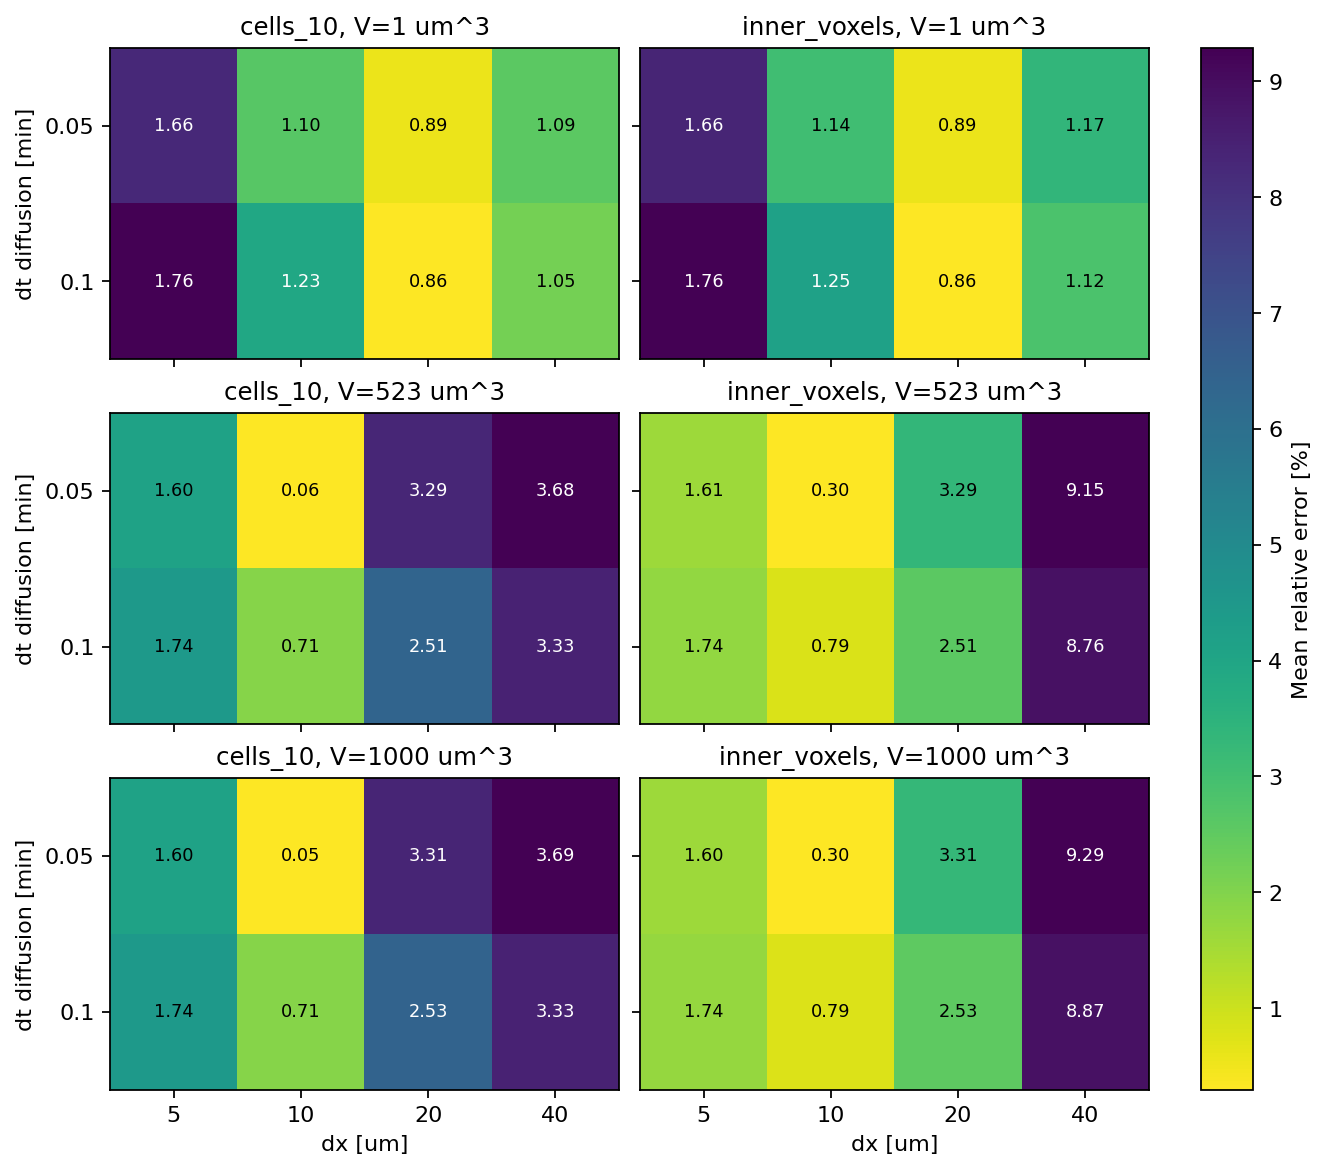

In [25]:
# A lower number is better. Each panel is a compact view of all dx and dt combinations for one volume.
fig, axes = plt.subplots(len(TOTAL_VOLUMES_UM3), len(LAYOUTS), figsize=(8.2, 7.2), sharex=True, sharey=True, constrained_layout=True)
for row, volume in enumerate(TOTAL_VOLUMES_UM3):
    for column, layout in enumerate(LAYOUTS):
        matrix = (metrics[(metrics['total_volume_um3'] == volume) & (metrics['layout'] == layout)]
            .pivot(index='dt_diffusion_min', columns='dx_um', values='mean_relative_error_percent')
            .reindex(index=DT_DIFFUSION_MIN, columns=VOXEL_SIZES_UM))
        axis = axes[row, column]
        image = axis.imshow(matrix, aspect='auto', cmap='viridis_r')
        axis.set_title(f'{layout}, V={volume:g} um^3')
        axis.set_xticks(range(len(VOXEL_SIZES_UM)), [f'{dx:g}' for dx in VOXEL_SIZES_UM])
        axis.set_yticks(range(len(DT_DIFFUSION_MIN)), [f'{dt:g}' for dt in DT_DIFFUSION_MIN])
        for (y_index, x_index), value in np.ndenumerate(matrix.to_numpy()):
            axis.text(x_index, y_index, f'{value:.2f}', ha='center', va='center', color='white' if value > matrix.to_numpy().mean() else 'black', fontsize=8)
        if row == len(TOTAL_VOLUMES_UM3) - 1:
            axis.set_xlabel('dx [um]')
        if column == 0:
            axis.set_ylabel('dt diffusion [min]')
fig.colorbar(image, ax=axes, label='Mean relative error [%]')
plt.show()

## Direct Layout Comparison

Calculate the signed error difference between inner-voxel and `cells_10` placement for matching numerical parameters. Negative values favor the inner-voxel layout.

layout,dx_um,dt_diffusion_min,total_volume_um3,cells_10,inner_voxels,inner_voxels_minus_cells_10_percent
5,5.0,0.10,1000.0,1.737264,1.736876,-3.882214e-04
14,20.0,0.05,1000.0,3.308699,3.308699,-2.220446e-15
16,20.0,0.10,523.0,2.513251,2.513251,-4.440892e-16
12,20.0,0.05,1.0,0.889694,0.889694,-2.220446e-16
17,20.0,0.10,1000.0,2.526050,2.526050,1.332268e-15
15,20.0,0.10,1.0,0.864585,0.864585,1.554312e-15
13,20.0,0.05,523.0,3.289404,3.289404,1.776357e-15
4,5.0,0.10,523.0,1.737284,1.737651,3.669388e-04
3,5.0,0.10,1.0,1.757175,1.758140,9.646323e-04
2,5.0,0.05,1000.0,1.596204,1.601733,5.528523e-03


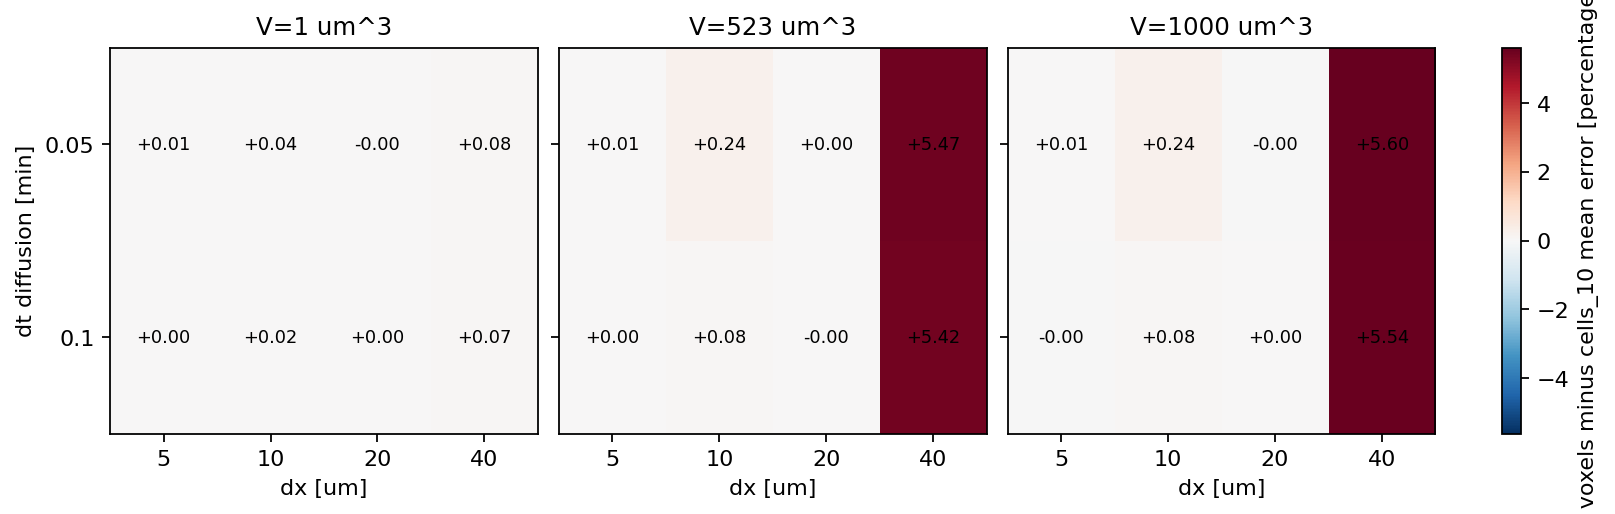

,better_layout,cases_won
0,cells_10,20
1,inner_voxels,4


In [26]:
paired = (metrics.pivot(index=['dx_um', 'dt_diffusion_min', 'total_volume_um3'], columns='layout', values='mean_relative_error_percent').reset_index())
paired['inner_voxels_minus_cells_10_percent'] = paired['inner_voxels'] - paired['cells_10']
display(paired.sort_values('inner_voxels_minus_cells_10_percent'))

fig, axes = plt.subplots(1, len(TOTAL_VOLUMES_UM3), figsize=(10, 3.1), sharey=True, constrained_layout=True)
limit = max(abs(paired['inner_voxels_minus_cells_10_percent'].min()), abs(paired['inner_voxels_minus_cells_10_percent'].max()))
for axis, volume in zip(axes, TOTAL_VOLUMES_UM3):
    matrix = (paired[paired['total_volume_um3'] == volume]
        .pivot(index='dt_diffusion_min', columns='dx_um', values='inner_voxels_minus_cells_10_percent')
        .reindex(index=DT_DIFFUSION_MIN, columns=VOXEL_SIZES_UM))
    image = axis.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit)
    axis.set_title(f'V={volume:g} um^3')
    axis.set_xticks(range(len(VOXEL_SIZES_UM)), [f'{dx:g}' for dx in VOXEL_SIZES_UM])
    axis.set_yticks(range(len(DT_DIFFUSION_MIN)), [f'{dt:g}' for dt in DT_DIFFUSION_MIN])
    axis.set_xlabel('dx [um]')
    for (y_index, x_index), value in np.ndenumerate(matrix.to_numpy()):
        axis.text(x_index, y_index, f'{value:+.2f}', ha='center', va='center', fontsize=8)
axes[0].set_ylabel('dt diffusion [min]')
fig.colorbar(image, ax=axes, label='Inner voxels minus cells_10 mean error [percentage points]')
plt.show()

wins = pd.Series(np.where(paired['inner_voxels_minus_cells_10_percent'] < 0, 'inner_voxels', 'cells_10')).value_counts().rename_axis('better_layout').reset_index(name='cases_won')
display(wins)

## Best `cells_10` Runs

Rank `cells_10` runs by average-concentration error and plot the five best traces against the analytical average.

,layout,run_id,dx_um,dt_diffusion_min,total_volume_um3,point_count,mean_absolute_error_uM,rmse_uM,mean_relative_error_percent,max_relative_error_percent
0,cells_10,cells_10__dx_10um__dtdiff_0p05min__volume_1000um3,10.0,0.05,1000.0,101,0.005313,0.005555,0.054239,0.063596
1,cells_10,cells_10__dx_10um__dtdiff_0p05min__volume_523um3,10.0,0.05,523.0,101,0.005510,0.005763,0.056258,0.065955
2,cells_10,cells_10__dx_10um__dtdiff_0p1min__volume_1000um3,10.0,0.10,1000.0,101,0.069428,0.071247,0.708631,0.782432
3,cells_10,cells_10__dx_10um__dtdiff_0p1min__volume_523um3,10.0,0.10,523.0,101,0.069507,0.071329,0.709440,0.783316
4,cells_10,cells_10__dx_20um__dtdiff_0p1min__volume_1um3,20.0,0.10,1.0,101,0.084691,0.087657,0.864585,0.986601


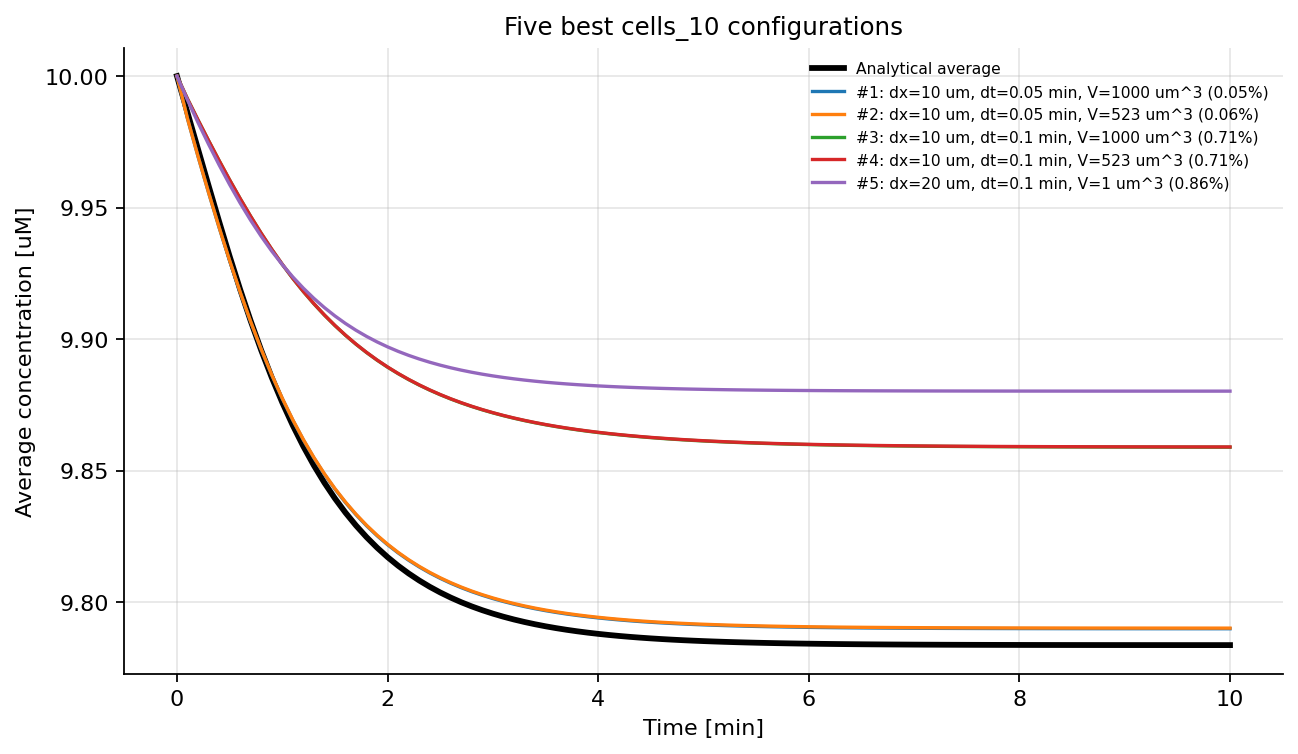

In [27]:
# Top five cells_10 configurations, ranked by mean relative error against the analytical average.
top_cells_10 = (metrics[metrics['layout'] == 'cells_10']
    .nsmallest(5, 'mean_relative_error_percent')
    .reset_index(drop=True))
display(top_cells_10)

fig, axis = plt.subplots(figsize=(8.0, 4.6), constrained_layout=True)
axis.plot(
    analytical['time_min'],
    analytical['average_concentration_uM'],
    color='black',
    linewidth=2.6,
    label='Analytical average',
)

for rank, configuration in top_cells_10.iterrows():
    trace = comparison[comparison['run_id'] == configuration['run_id']]
    label = (
        f"#{rank + 1}: dx={configuration['dx_um']:g} um, "
        f"dt={configuration['dt_diffusion_min']:g} min, "
        f"V={configuration['total_volume_um3']:g} um^3 "
        f"({configuration['mean_relative_error_percent']:.2f}%)"
    )
    axis.plot(trace['time_min'], trace['average_uM'], linewidth=1.5, label=label)

axis.set_xlabel('Time [min]')
axis.set_ylabel('Average concentration [uM]')
axis.set_title('Five best cells_10 configurations')
axis.grid(True, alpha=0.3)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.legend(frameon=False, fontsize=7, loc='best')
plt.show()

## Best Inner-Voxel Runs

Apply the same five-run ranking to the inner-voxel layout, using the analytical average as the reference.

,layout,run_id,dx_um,dt_diffusion_min,total_volume_um3,point_count,mean_absolute_error_uM,rmse_uM,mean_relative_error_percent,max_relative_error_percent
0,inner_voxels,inner_voxels__dx_10um__dtdiff_0p05min__volume_...,10.0,0.05,1000.0,101,0.029228,0.030361,0.298399,0.340489
1,inner_voxels,inner_voxels__dx_10um__dtdiff_0p05min__volume_...,10.0,0.05,523.0,101,0.029381,0.030518,0.299959,0.342230
2,inner_voxels,inner_voxels__dx_10um__dtdiff_0p1min__volume_1...,10.0,0.10,1000.0,101,0.076991,0.079076,0.785846,0.867684
3,inner_voxels,inner_voxels__dx_10um__dtdiff_0p1min__volume_5...,10.0,0.10,523.0,101,0.077059,0.079146,0.786542,0.868454
4,inner_voxels,inner_voxels__dx_20um__dtdiff_0p1min__volume_1um3,20.0,0.10,1.0,101,0.084691,0.087657,0.864585,0.986601


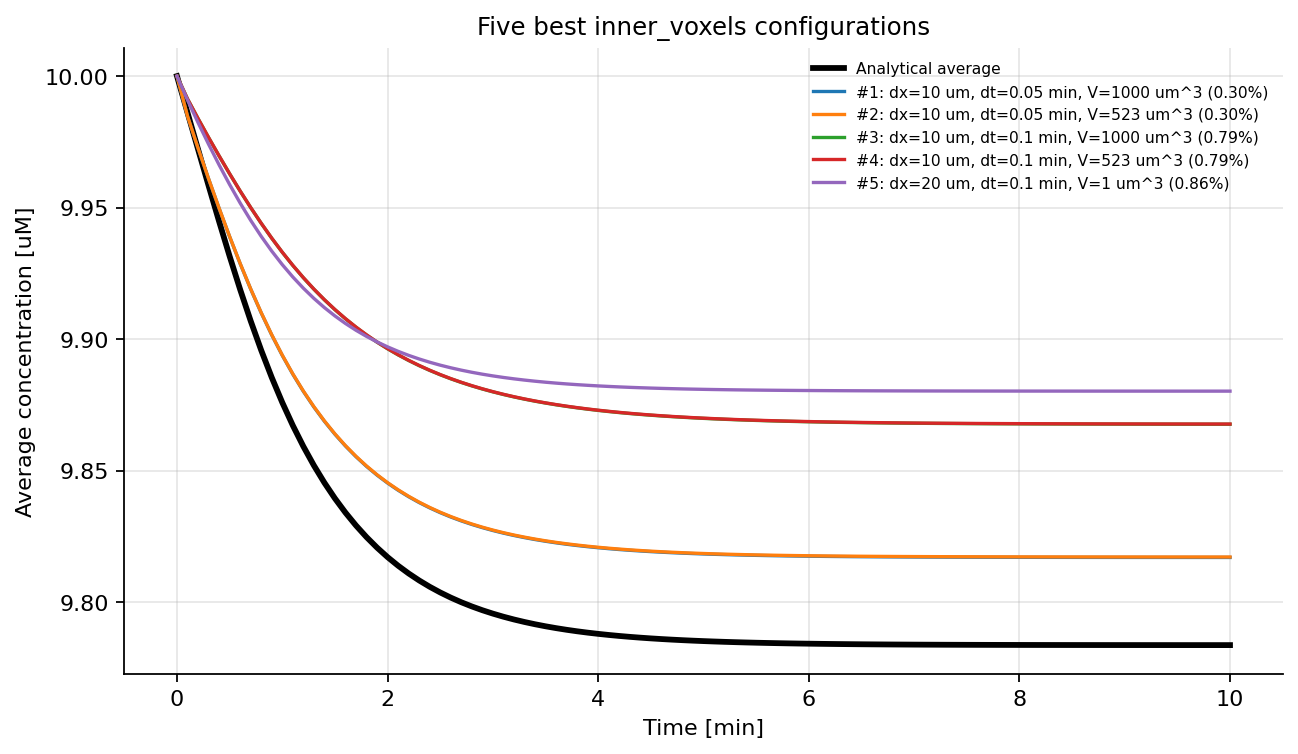

In [28]:
# Top five inner_voxels configurations, ranked by mean relative error against the analytical average.
top_inner_voxels = (metrics[metrics['layout'] == 'inner_voxels']
    .nsmallest(5, 'mean_relative_error_percent')
    .reset_index(drop=True))
display(top_inner_voxels)

fig, axis = plt.subplots(figsize=(8.0, 4.6), constrained_layout=True)
axis.plot(
    analytical['time_min'],
    analytical['average_concentration_uM'],
    color='black',
    linewidth=2.6,
    label='Analytical average',
)

for rank, configuration in top_inner_voxels.iterrows():
    trace = comparison[comparison['run_id'] == configuration['run_id']]
    label = (
        f"#{rank + 1}: dx={configuration['dx_um']:g} um, "
        f"dt={configuration['dt_diffusion_min']:g} min, "
        f"V={configuration['total_volume_um3']:g} um^3 "
        f"({configuration['mean_relative_error_percent']:.2f}%)"
    )
    axis.plot(trace['time_min'], trace['average_uM'], linewidth=1.5, label=label)

axis.set_xlabel('Time [min]')
axis.set_ylabel('Average concentration [uM]')
axis.set_title('Five best inner_voxels configurations')
axis.grid(True, alpha=0.3)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.legend(frameon=False, fontsize=7, loc='best')
plt.show()

## Center and Cell-Site Estimators

Compare all center estimators with the analytical center concentration. Summarize cell-site measures separately because they represent the concentration experienced by cells, not the center.

,layout,method,mean_absolute_error_uM
1,cells_10,Lower center voxel,1.525496
0,cells_10,Gaussian-smoothed center,1.567057
2,cells_10,Mean of 8 surrounding voxels,2.321636
3,cells_10,Spherical center neighborhood,2.321636
4,cells_10,Trilinear interpolation,2.321636
5,cells_10,Upper center voxel,3.393159
6,inner_voxels,Gaussian-smoothed center,1.476186
11,inner_voxels,Upper center voxel,1.513592
8,inner_voxels,Mean of 8 surrounding voxels,2.840773
9,inner_voxels,Spherical center neighborhood,2.840773


,layout,dx_um,dt_diffusion_min,total_volume_um3,cell_voxel_average_uM,cell_voxel_window_average_uM,cell_trilinear_average_uM,cell_inverse_distance_average_uM,cell_spherical_average_uM,cell_gaussian_average_uM
0,cells_10,5.0,0.05,1.0,9.784398,9.682119,9.780683,9.743967,9.780683,9.780683
1,cells_10,5.0,0.05,523.0,9.741860,9.619427,9.737412,9.693468,9.737143,9.714125
2,cells_10,5.0,0.05,1000.0,9.741813,9.619358,9.737365,9.693413,9.737095,9.703208
3,cells_10,5.0,0.10,1.0,9.881104,9.770194,9.879113,9.831900,9.879113,9.879113
4,cells_10,5.0,0.10,523.0,9.869057,9.746917,9.866865,9.814873,9.866907,9.842721


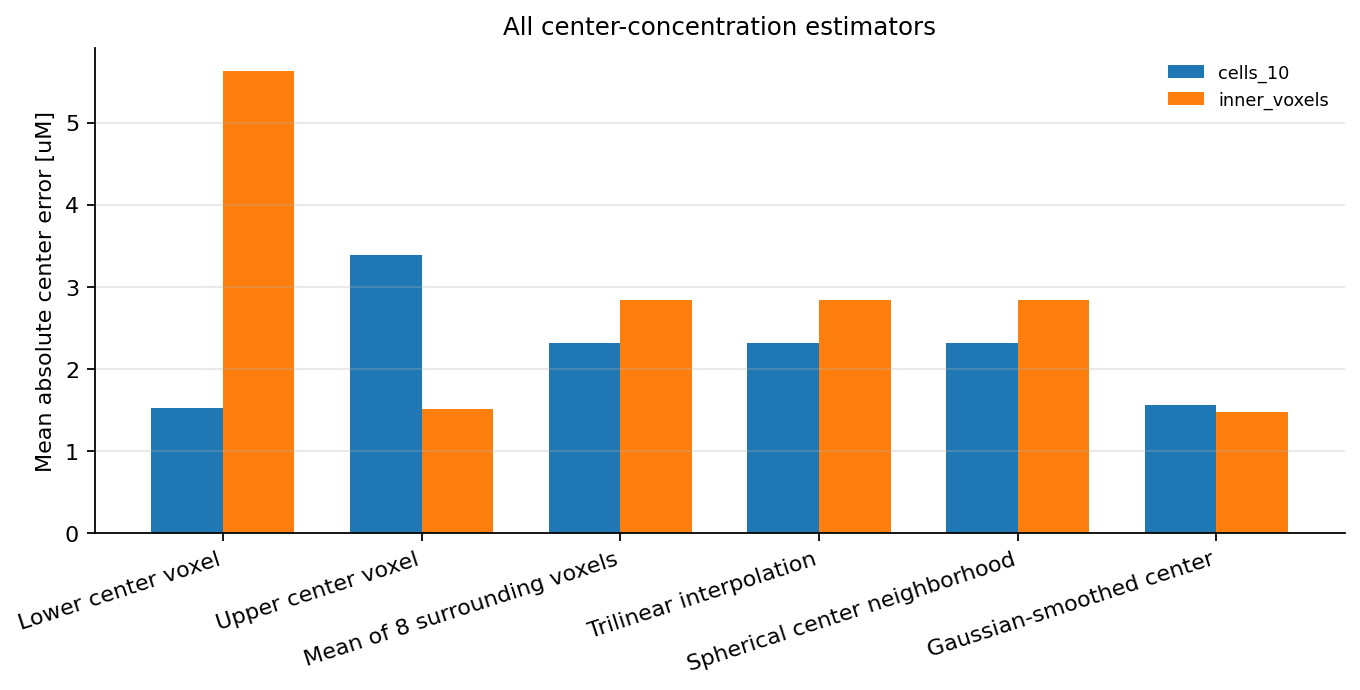

In [29]:
# Extended analysis: center estimators use the analytical center reference; cell-site methods remain a separate measure.
if 'comparison' not in globals():
    comparison = pd.read_csv(RESULTS_ROOT / 'position_comparison_timeseries.csv')

extended_center_methods = {
    'Lower center voxel': 'center_lower_voxel_uM',
    'Upper center voxel': 'center_upper_voxel_uM',
    'Mean of 8 surrounding voxels': 'center_corner_mean_uM',
    'Trilinear interpolation': 'center_trilinear_uM',
    'Spherical center neighborhood': 'center_spherical_average_uM',
    'Gaussian-smoothed center': 'center_gaussian_uM',
}
extended_center_records = []
for method, column in extended_center_methods.items():
    method_frame = comparison[['layout', 'run_id', 'dx_um', 'dt_diffusion_min', 'total_volume_um3', 'time_min', 'center_concentration_uM', column]].copy()
    method_frame['method'] = method
    method_frame['absolute_error_uM'] = (method_frame[column] - method_frame['center_concentration_uM']).abs()
    extended_center_records.append(method_frame)
extended_center_metrics = (pd.concat(extended_center_records, ignore_index=True)
    .groupby(['layout', 'method'], as_index=False)
    .agg(mean_absolute_error_uM=('absolute_error_uM', 'mean')))
extended_center_metrics.to_csv(RESULTS_ROOT / 'extended_center_estimator_metrics_by_layout.csv', index=False)
display(extended_center_metrics.sort_values(['layout', 'mean_absolute_error_uM']))

cell_site_methods = {
    'Cell-containing voxels': 'cell_voxel_average_uM',
    'One-voxel cell neighborhood': 'cell_voxel_window_average_uM',
    'Cell-coordinate trilinear': 'cell_trilinear_average_uM',
    'Cell local inverse-distance': 'cell_inverse_distance_average_uM',
    'Cell spherical neighborhood': 'cell_spherical_average_uM',
    'Cell Gaussian-smoothed': 'cell_gaussian_average_uM',
}
cell_site_summary = (comparison.groupby(['layout', 'dx_um', 'dt_diffusion_min', 'total_volume_um3'], as_index=False)
    .agg({column: 'mean' for column in cell_site_methods.values()}))
cell_site_summary.to_csv(RESULTS_ROOT / 'cell_site_concentration_summary.csv', index=False)
display(cell_site_summary.head())

fig, axis = plt.subplots(figsize=(8.4, 4.2), constrained_layout=True)
plot_metrics = extended_center_metrics.pivot(index='method', columns='layout', values='mean_absolute_error_uM')
plot_metrics = plot_metrics.loc[list(extended_center_methods)]
positions = np.arange(len(plot_metrics))
bar_width = 0.36
for offset, layout in zip((-bar_width / 2, bar_width / 2), plot_metrics.columns):
    axis.bar(positions + offset, plot_metrics[layout], width=bar_width, label=layout)
axis.set_xticks(positions, plot_metrics.index, rotation=18, ha='right')
axis.set_ylabel('Mean absolute center error [uM]')
axis.set_title('All center-concentration estimators')
axis.grid(True, axis='y', alpha=0.3)
axis.spines['top'].set_visible(False)
axis.spines['right'].set_visible(False)
axis.legend(frameon=False)
plt.show()

## Best Average Configuration at Each `dx`

For each layout and `dx`, select the diffusion step and volume with the smallest average-concentration error, then plot its trace.

,layout,dx_um,dt_diffusion_min,total_volume_um3,mean_relative_error_percent
0,cells_10,5.0,0.05,1000.0,1.596204
1,cells_10,10.0,0.05,1000.0,0.054239
2,cells_10,20.0,0.10,1.0,0.864585
3,cells_10,40.0,0.10,1.0,1.050729
4,inner_voxels,5.0,0.05,1000.0,1.601733
5,inner_voxels,10.0,0.05,1000.0,0.298399
6,inner_voxels,20.0,0.10,1.0,0.864585
7,inner_voxels,40.0,0.10,1.0,1.116991


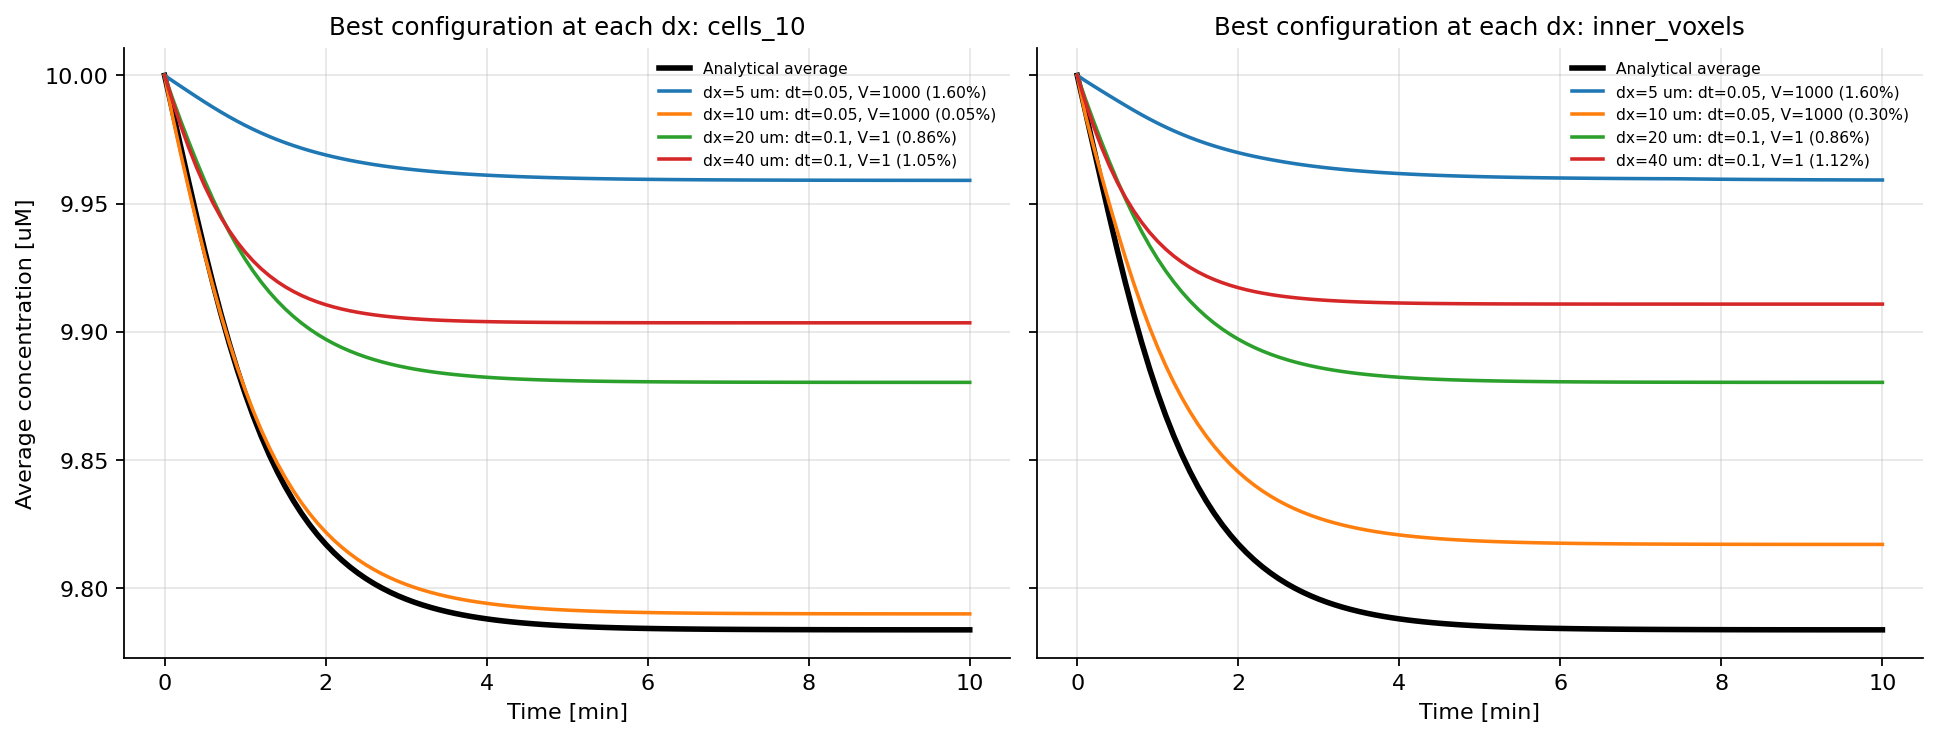

In [30]:
# For each cell-position layout and each dx, select the dt and volume with the lowest average-concentration error.
best_by_layout_and_dx = (metrics.loc[
    metrics.groupby(['layout', 'dx_um'])['mean_relative_error_percent'].idxmin()
].sort_values(['layout', 'dx_um']).reset_index(drop=True))
display(best_by_layout_and_dx[['layout', 'dx_um', 'dt_diffusion_min', 'total_volume_um3', 'mean_relative_error_percent']])

fig, axes = plt.subplots(1, len(LAYOUTS), figsize=(12, 4.5), sharey=True, constrained_layout=True)
for axis, layout in zip(axes, LAYOUTS):
    axis.plot(
        analytical['time_min'],
        analytical['average_concentration_uM'],
        color='black',
        linewidth=2.5,
        label='Analytical average',
    )
    layout_best = best_by_layout_and_dx[best_by_layout_and_dx['layout'] == layout]
    for _, configuration in layout_best.iterrows():
        trace = comparison[comparison['run_id'] == configuration['run_id']]
        label = (
            f"dx={configuration['dx_um']:g} um: "
            f"dt={configuration['dt_diffusion_min']:g}, "
            f"V={configuration['total_volume_um3']:g} "
            f"({configuration['mean_relative_error_percent']:.2f}%)"
        )
        axis.plot(trace['time_min'], trace['average_uM'], linewidth=1.6, label=label)
    axis.set_title(f'Best configuration at each dx: {layout}')
    axis.set_xlabel('Time [min]')
    axis.grid(True, alpha=0.3)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.legend(frameon=False, fontsize=7)
axes[0].set_ylabel('Average concentration [uM]')
plt.show()

## Center Errors of the Selected Runs

For the configurations selected by average accuracy, calculate mean absolute center error for every center estimator and save the comparison table.

In [31]:
# Center errors for the configurations selected above by their average-concentration accuracy.
center_methods_for_best_average = {
    'Lower voxel': 'center_lower_voxel_uM',
    'Upper voxel': 'center_upper_voxel_uM',
    '8-voxel mean': 'center_corner_mean_uM',
    'Trilinear': 'center_trilinear_uM',
    'Spherical': 'center_spherical_average_uM',
    'Gaussian': 'center_gaussian_uM',
}
selected_run_ids = best_by_layout_and_dx['run_id'].tolist()
center_error_records = []
for method, column in center_methods_for_best_average.items():
    selected_trace = comparison[comparison['run_id'].isin(selected_run_ids)]
    method_error = (selected_trace[column] - selected_trace['center_concentration_uM']).abs()
    summary = (selected_trace.assign(center_method=method, center_absolute_error_uM=method_error)
        .groupby(['layout', 'dx_um', 'dt_diffusion_min', 'total_volume_um3', 'center_method'], as_index=False)
        .agg(mean_center_absolute_error_uM=('center_absolute_error_uM', 'mean')))
    center_error_records.append(summary)

best_average_center_errors = pd.concat(center_error_records, ignore_index=True)
center_error_table = (best_average_center_errors.pivot(
    index=['layout', 'dx_um', 'dt_diffusion_min', 'total_volume_um3'],
    columns='center_method',
    values='mean_center_absolute_error_uM',
).reindex(columns=center_methods_for_best_average).reset_index())
center_error_table.to_csv(RESULTS_ROOT / 'best_average_configurations_center_errors.csv', index=False)
display(center_error_table)

center_method,layout,dx_um,dt_diffusion_min,total_volume_um3,Lower voxel,Upper voxel,8-voxel mean,Trilinear,Spherical,Gaussian
0,cells_10,5.0,0.05,1000.0,2.336797,2.302829,2.317634,2.317634,2.317634,2.253120
1,cells_10,10.0,0.05,1000.0,0.616572,0.293323,0.479976,0.479976,0.479976,0.071650
2,cells_10,20.0,0.10,1.0,1.850754,0.153914,0.985064,0.985064,0.985064,1.498347
3,cells_10,40.0,0.10,1.0,2.261586,1.025367,1.643476,1.643476,1.643476,2.209419
4,inner_voxels,5.0,0.05,1000.0,6.591891,1.977067,2.578857,2.578857,2.578857,0.651374
5,inner_voxels,10.0,0.05,1000.0,7.174218,0.056965,3.615592,3.615592,3.615592,1.864260
6,inner_voxels,20.0,0.10,1.0,0.153914,1.850754,0.985064,0.985064,0.985064,1.498264
7,inner_voxels,40.0,0.10,1.0,1.831459,2.408637,2.120048,2.120048,2.120048,2.343608


## Center-Error Plot for Selected Runs

Plot the center-error table by `dx` and layout to reveal which center estimator is most accurate within each best-average configuration.

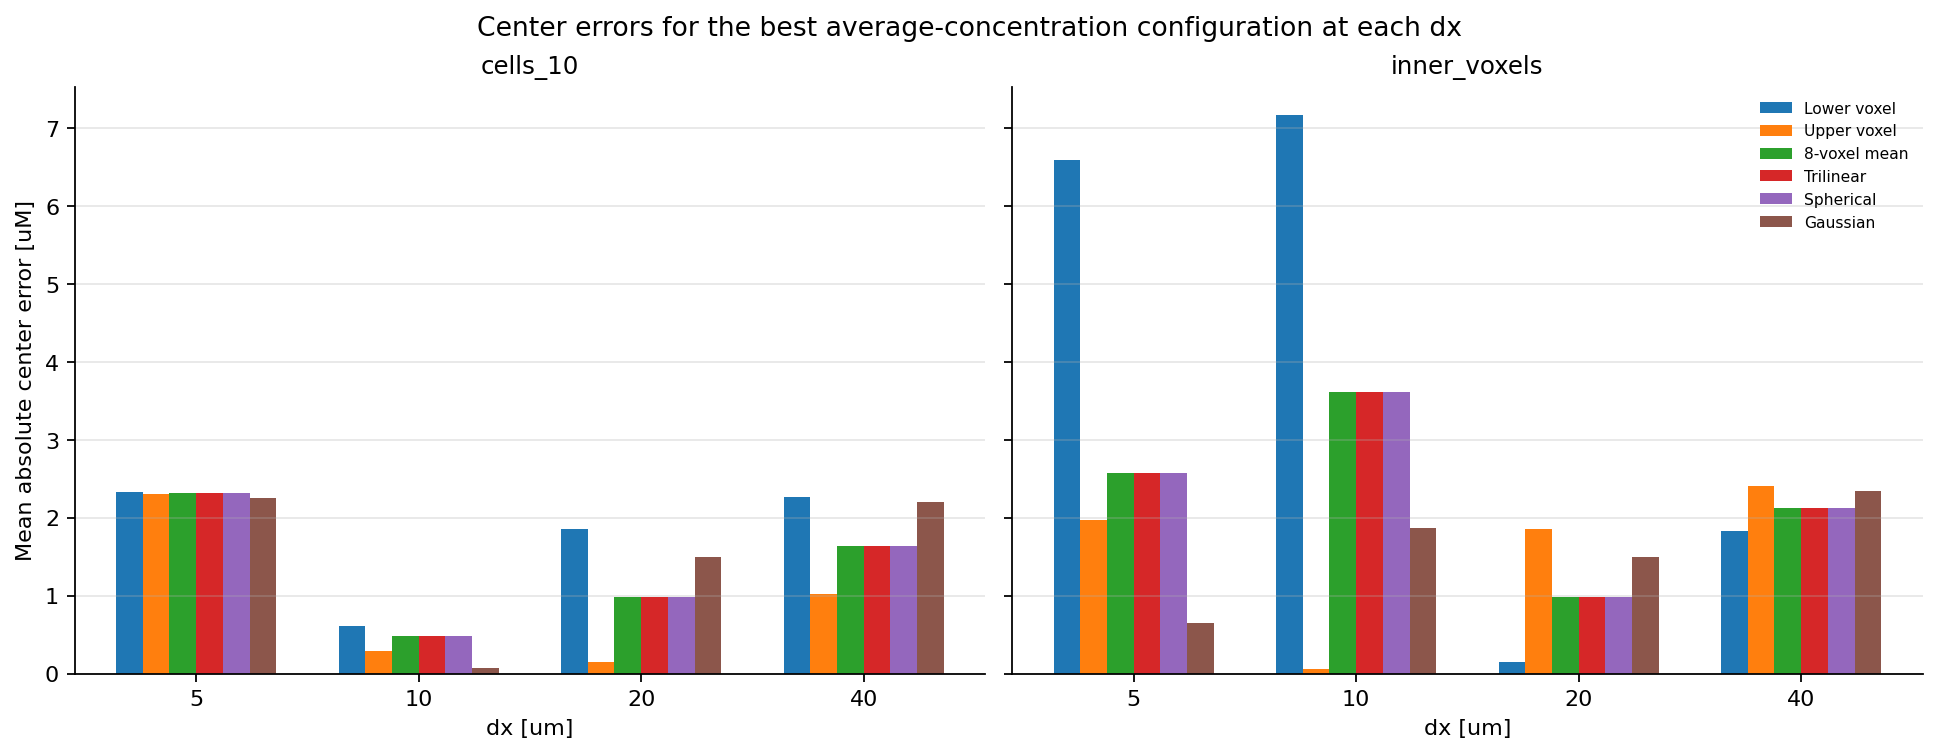

In [32]:
# Visual comparison of center estimators for the per-dx best average-concentration configurations.
method_names = list(center_methods_for_best_average)
fig, axes = plt.subplots(1, len(LAYOUTS), figsize=(12, 4.6), sharey=True, constrained_layout=True)
bar_width = 0.12
for axis, layout in zip(axes, LAYOUTS):
    layout_errors = center_error_table[center_error_table['layout'] == layout].sort_values('dx_um')
    positions = np.arange(len(layout_errors))
    for method_index, method in enumerate(method_names):
        offset = (method_index - (len(method_names) - 1) / 2) * bar_width
        axis.bar(positions + offset, layout_errors[method], width=bar_width, label=method)
    axis.set_title(layout)
    axis.set_xticks(positions, [f"{dx:g}" for dx in layout_errors['dx_um']])
    axis.set_xlabel('dx [um]')
    axis.grid(True, axis='y', alpha=0.3)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
axes[0].set_ylabel('Mean absolute center error [uM]')
axes[1].legend(frameon=False, fontsize=7, loc='upper right')
fig.suptitle('Center errors for the best average-concentration configuration at each dx')
plt.show()

## Results at `dt=0.1 min`

This section reads the completed sweep outputs without running PhysiCell again. It reports mean absolute error against the analytical domain average and against the analytical center concentration for every saved center estimator.

,layout,dx_um,total_volume_um3,mean_average_absolute_error_uM
0,cells_10,5.0,1.0,0.172139
3,cells_10,10.0,1.0,0.120158
6,cells_10,20.0,1.0,0.084691
9,cells_10,40.0,1.0,0.102911
1,cells_10,5.0,523.0,0.170191
4,cells_10,10.0,523.0,0.069507
7,cells_10,20.0,523.0,0.246293
10,cells_10,40.0,523.0,0.326818
2,cells_10,5.0,1000.0,0.170189
5,cells_10,10.0,1000.0,0.069428


center_method,layout,dx_um,total_volume_um3,Lower voxel,Upper voxel,8-voxel mean,Trilinear,Spherical,Gaussian
0,cells_10,5.0,1.0,2.545169,2.527671,2.535841,2.535841,2.535841,2.473119
3,cells_10,10.0,1.0,2.020346,1.900803,1.333833,1.333833,1.333833,1.601943
6,cells_10,20.0,1.0,1.850754,0.153914,0.985064,0.985064,0.985064,1.498347
9,cells_10,40.0,1.0,2.261586,1.025367,1.643476,1.643476,1.643476,2.209419
1,cells_10,5.0,523.0,2.527724,2.508455,2.517452,2.517452,2.517452,2.448398
4,cells_10,10.0,523.0,1.527985,1.324487,0.374093,0.374093,0.374093,0.819643
7,cells_10,20.0,523.0,0.784920,7.133904,3.946176,3.946176,3.946176,2.163390
10,cells_10,40.0,523.0,0.056422,7.181397,3.567884,3.567884,3.567884,0.257041
2,cells_10,5.0,1000.0,2.527706,2.508436,2.517434,2.517434,2.517434,2.448373
5,cells_10,10.0,1000.0,1.527217,1.323588,0.372659,0.372659,0.372659,0.818427


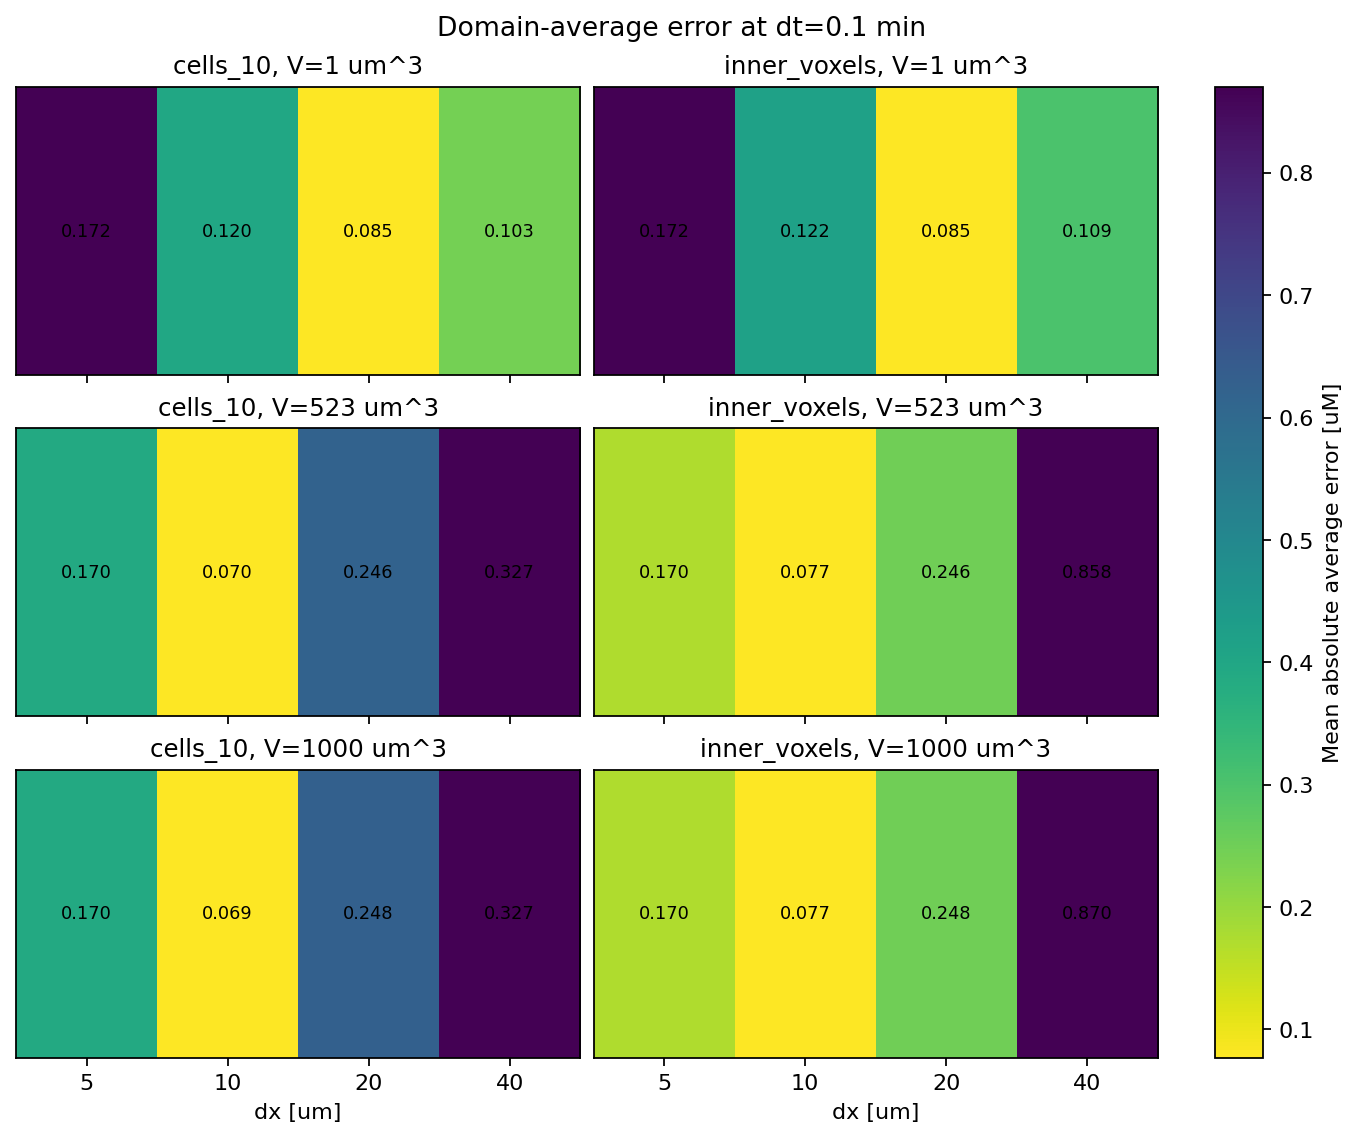

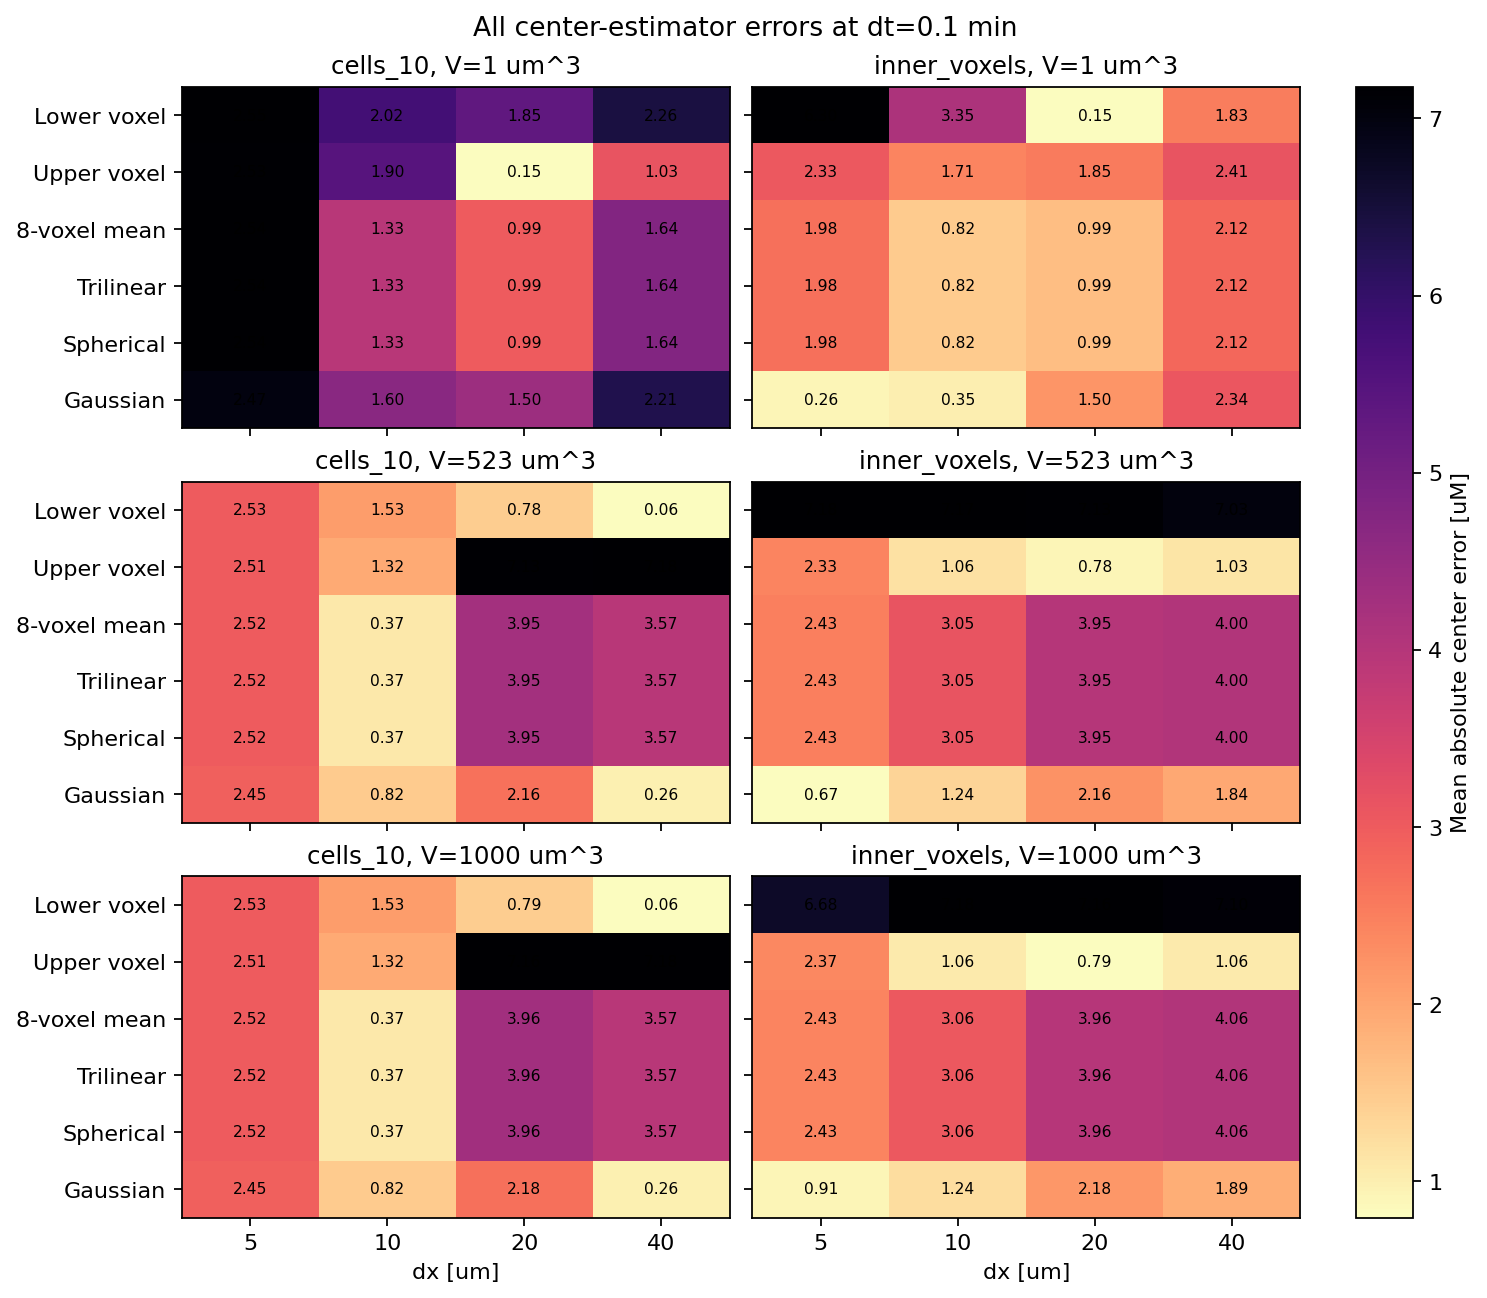

In [33]:
# Present existing dt=0.1 results only; this cell does not run simulations.
if 'comparison' not in globals():
    comparison = pd.read_csv(RESULTS_ROOT / 'position_comparison_timeseries.csv')

DT_RESULTS = 0.1
center_methods_dt = {
    'Lower voxel': 'center_lower_voxel_uM',
    'Upper voxel': 'center_upper_voxel_uM',
    '8-voxel mean': 'center_corner_mean_uM',
    'Trilinear': 'center_trilinear_uM',
    'Spherical': 'center_spherical_average_uM',
    'Gaussian': 'center_gaussian_uM',
}
dt_results = comparison[np.isclose(comparison['dt_diffusion_min'], DT_RESULTS)].copy()
dt_results['average_absolute_error_uM'] = (dt_results['average_uM'] - dt_results['average_concentration_uM']).abs()

average_results_dt = (dt_results.groupby(['layout', 'dx_um', 'total_volume_um3'], as_index=False)
    .agg(mean_average_absolute_error_uM=('average_absolute_error_uM', 'mean')))
display(average_results_dt.sort_values(['layout', 'total_volume_um3', 'dx_um']))

center_result_records = []
for method, column in center_methods_dt.items():
    result = dt_results[['layout', 'dx_um', 'total_volume_um3', 'center_concentration_uM', column]].copy()
    result['center_method'] = method
    result['mean_center_absolute_error_uM'] = (result[column] - result['center_concentration_uM']).abs()
    center_result_records.append(result)
center_results_dt = (pd.concat(center_result_records, ignore_index=True)
    .groupby(['layout', 'dx_um', 'total_volume_um3', 'center_method'], as_index=False)
    .agg(mean_center_absolute_error_uM=('mean_center_absolute_error_uM', 'mean')))
center_results_table_dt = (center_results_dt.pivot(
    index=['layout', 'dx_um', 'total_volume_um3'],
    columns='center_method',
    values='mean_center_absolute_error_uM',
).reindex(columns=list(center_methods_dt)).reset_index())
display(center_results_table_dt.sort_values(['layout', 'total_volume_um3', 'dx_um']))

fig, axes = plt.subplots(len(TOTAL_VOLUMES_UM3), len(LAYOUTS), figsize=(8.4, 7.0), sharex=True, constrained_layout=True)
for row, volume in enumerate(TOTAL_VOLUMES_UM3):
    for column, layout in enumerate(LAYOUTS):
        matrix = (average_results_dt[(average_results_dt['layout'] == layout) & (average_results_dt['total_volume_um3'] == volume)]
            .pivot(index='total_volume_um3', columns='dx_um', values='mean_average_absolute_error_uM')
            .reindex(columns=VOXEL_SIZES_UM))
        axis = axes[row, column]
        image = axis.imshow(matrix, aspect='auto', cmap='viridis_r')
        axis.set_title(f'{layout}, V={volume:g} um^3')
        axis.set_xticks(range(len(VOXEL_SIZES_UM)), [f'{dx:g}' for dx in VOXEL_SIZES_UM])
        axis.set_yticks([])
        for x_index, value in enumerate(matrix.iloc[0]):
            axis.text(x_index, 0, f'{value:.3f}', ha='center', va='center', fontsize=8)
        if row == len(TOTAL_VOLUMES_UM3) - 1:
            axis.set_xlabel('dx [um]')
fig.colorbar(image, ax=axes, label='Mean absolute average error [uM]')
fig.suptitle('Domain-average error at dt=0.1 min')
plt.show()

fig, axes = plt.subplots(len(TOTAL_VOLUMES_UM3), len(LAYOUTS), figsize=(9.2, 8.0), sharex=True, constrained_layout=True)
for row, volume in enumerate(TOTAL_VOLUMES_UM3):
    for column, layout in enumerate(LAYOUTS):
        matrix = (center_results_dt[(center_results_dt['layout'] == layout) & (center_results_dt['total_volume_um3'] == volume)]
            .pivot(index='center_method', columns='dx_um', values='mean_center_absolute_error_uM')
            .reindex(index=list(center_methods_dt), columns=VOXEL_SIZES_UM))
        axis = axes[row, column]
        image = axis.imshow(matrix, aspect='auto', cmap='magma_r')
        axis.set_title(f'{layout}, V={volume:g} um^3')
        axis.set_xticks(range(len(VOXEL_SIZES_UM)), [f'{dx:g}' for dx in VOXEL_SIZES_UM])
        axis.set_yticks(range(len(center_methods_dt)), list(center_methods_dt) if column == 0 else [])
        for (y_index, x_index), value in np.ndenumerate(matrix.to_numpy()):
            axis.text(x_index, y_index, f'{value:.2f}', ha='center', va='center', fontsize=7)
        if row == len(TOTAL_VOLUMES_UM3) - 1:
            axis.set_xlabel('dx [um]')
fig.colorbar(image, ax=axes, label='Mean absolute center error [uM]')
fig.suptitle('All center-estimator errors at dt=0.1 min')
plt.show()

## `dt=0.1 min`: Fixed Cell Positions

This focused view filters the existing results to the fixed positions from `cells_10.csv`. It presents domain-average and all center-estimator errors without rerunning PhysiCell.

dx_um,5.0,10.0,20.0,40.0
total_volume_um3,,,,
1.0,0.172139,0.120158,0.084691,0.102911
523.0,0.170191,0.069507,0.246293,0.326818
1000.0,0.170189,0.069428,0.247547,0.326913


center_method,total_volume_um3,dx_um,Lower voxel,Upper voxel,8-voxel mean,Trilinear,Spherical,Gaussian
0,1.0,5.0,2.545169,2.527671,2.535841,2.535841,2.535841,2.473119
1,1.0,10.0,2.020346,1.900803,1.333833,1.333833,1.333833,1.601943
2,1.0,20.0,1.850754,0.153914,0.985064,0.985064,0.985064,1.498347
3,1.0,40.0,2.261586,1.025367,1.643476,1.643476,1.643476,2.209419
4,523.0,5.0,2.527724,2.508455,2.517452,2.517452,2.517452,2.448398
5,523.0,10.0,1.527985,1.324487,0.374093,0.374093,0.374093,0.819643
6,523.0,20.0,0.784920,7.133904,3.946176,3.946176,3.946176,2.163390
7,523.0,40.0,0.056422,7.181397,3.567884,3.567884,3.567884,0.257041
8,1000.0,5.0,2.527706,2.508436,2.517434,2.517434,2.517434,2.448373
9,1000.0,10.0,1.527217,1.323588,0.372659,0.372659,0.372659,0.818427


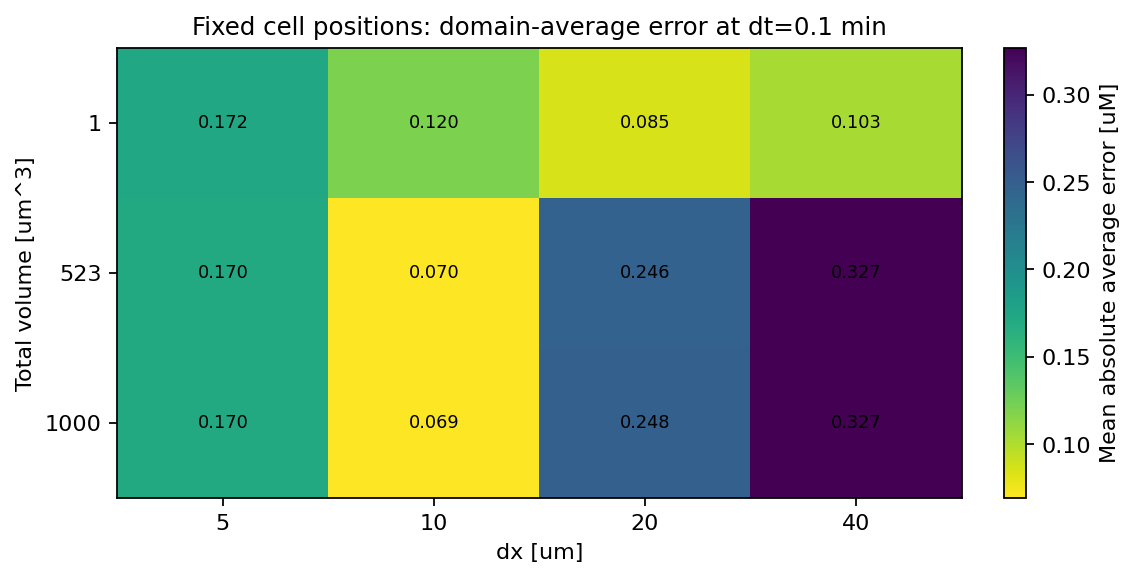

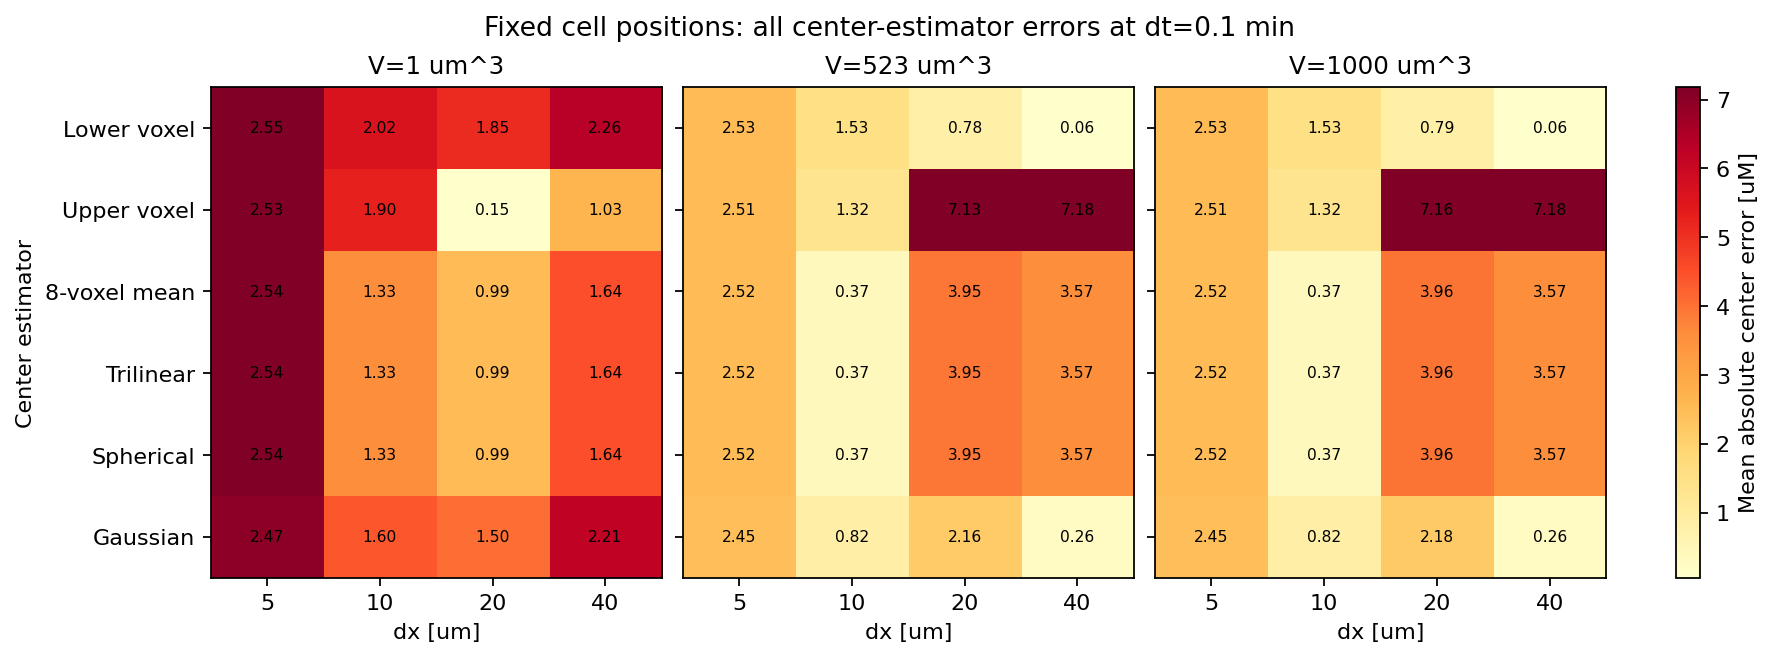

In [34]:
# Fixed cell positions at dt=0.1 min; reads completed results only.
fixed_dt_results = dt_results[dt_results['layout'] == 'cells_10'].copy()
fixed_average_results = average_results_dt[average_results_dt['layout'] == 'cells_10'].copy()
fixed_center_results = center_results_dt[center_results_dt['layout'] == 'cells_10'].copy()

fixed_average_table = (fixed_average_results.pivot(
    index='total_volume_um3',
    columns='dx_um',
    values='mean_average_absolute_error_uM',
).reindex(index=TOTAL_VOLUMES_UM3, columns=VOXEL_SIZES_UM))
display(fixed_average_table)

fixed_center_table = (fixed_center_results.pivot(
    index=['total_volume_um3', 'dx_um'],
    columns='center_method',
    values='mean_center_absolute_error_uM',
).reindex(columns=list(center_methods_dt)).reset_index())
display(fixed_center_table)

fig, axis = plt.subplots(figsize=(7.0, 3.5), constrained_layout=True)
image = axis.imshow(fixed_average_table, aspect='auto', cmap='viridis_r')
axis.set_title('Fixed cell positions: domain-average error at dt=0.1 min')
axis.set_xticks(range(len(VOXEL_SIZES_UM)), [f'{dx:g}' for dx in VOXEL_SIZES_UM])
axis.set_yticks(range(len(TOTAL_VOLUMES_UM3)), [f'{volume:g}' for volume in TOTAL_VOLUMES_UM3])
axis.set_xlabel('dx [um]')
axis.set_ylabel('Total volume [um^3]')
for (y_index, x_index), value in np.ndenumerate(fixed_average_table.to_numpy()):
    axis.text(x_index, y_index, f'{value:.3f}', ha='center', va='center', fontsize=8)
fig.colorbar(image, ax=axis, label='Mean absolute average error [uM]')
plt.show()

fig, axes = plt.subplots(1, len(TOTAL_VOLUMES_UM3), figsize=(11.0, 4.0), sharey=True, constrained_layout=True)
for axis, volume in zip(axes, TOTAL_VOLUMES_UM3):
    matrix = (fixed_center_results[fixed_center_results['total_volume_um3'] == volume]
        .pivot(index='center_method', columns='dx_um', values='mean_center_absolute_error_uM')
        .reindex(index=list(center_methods_dt), columns=VOXEL_SIZES_UM))
    image = axis.imshow(matrix, aspect='auto', cmap='YlOrRd')
    axis.set_title(f'V={volume:g} um^3')
    axis.set_xticks(range(len(VOXEL_SIZES_UM)), [f'{dx:g}' for dx in VOXEL_SIZES_UM])
    axis.set_xlabel('dx [um]')
    for (y_index, x_index), value in np.ndenumerate(matrix.to_numpy()):
        axis.text(x_index, y_index, f'{value:.2f}', ha='center', va='center', fontsize=7)
axes[0].set_yticks(range(len(center_methods_dt)), list(center_methods_dt))
axes[0].set_ylabel('Center estimator')
fig.colorbar(image, ax=axes, label='Mean absolute center error [uM]')
fig.suptitle('Fixed cell positions: all center-estimator errors at dt=0.1 min')
plt.show()

## Results Interpretation

For the analytical **domain average**, `cells_10` is the preferred placement. Its best case is `dx=10 um`, `dt=0.05 min`, and `V=1000 um^3`, with a mean relative error of `0.054%`; the corresponding inner-voxel case has `0.298%` error. At `dx=20 um`, both layouts give the same best average error because the layouts map to an equivalent voxel representation for that configuration. At `dx=5 um` and `dx=40 um`, `cells_10` is also slightly better.

The most accurate **center** estimator depends on both the layout and `dx`; there is no universal winner. For the selected best-average cases, the Gaussian estimate is strongest for `cells_10` at `dx=5` and `dx=10`, while the upper voxel is best at `dx=20` and `dx=40`. For inner voxels, Gaussian is best at `dx=5`, the upper voxel at `dx=10`, and the lower voxel at `dx=20` and `dx=40`.

Choose the metric according to the scientific question: use `average_uM` for agreement with the analytical domain average, a validated center estimator for concentration at `(0, 0, 0)`, and the cell-site measures for the concentration experienced by cells. Cell-site values should not be used as a center-concentration surrogate.